# VoxShield 전체 코드  
## 마이크 직접 녹음 + 원본 합성음 탐지 + Noise Focus 억양 분석

이 노트북은 다음 전체 과정을 실행합니다.

1. `Bisher/ASVspoof_2019_LA`로 사람 음성/합성·변조 음성 탐지 모델 학습  
2. 선택적으로 `HamdanXI/speech-accent-archive-v2`로 L1 영향 발화 패턴 모델 학습  
3. Colab 브라우저에서 마이크로 직접 녹음  
4. **원본에 가까운 녹음은 합성음 탐지 모델에 사용**  
5. **노이즈 감소·대역 필터·음량 정규화를 적용한 음성은 억양 패턴 분석에 사용**  
6. 품질, 발화 길이, 모델 점수, Top 3 패턴과 한계를 리포트로 표시

> Noise Focus는 배경 소음을 줄이고 발화 구간을 강조하는 기능입니다.  
> 여러 사람이 동시에 말할 때 특정 화자 한 명만 완벽하게 분리하는 기능은 아닙니다.

Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택하세요.

In [ ]:
from google.colab import auth

auth.authenticate_user()

In [ ]:
# ============================================================
# 0. Colab 패키지 설치
# ============================================================
!apt-get -qq update
!apt-get -qq install -y ffmpeg libsndfile1
!pip -q install "datasets[audio]" librosa soundfile scikit-learn tqdm huggingface_hub noisereduce

print("✅ 설치 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ 설치 완료


In [ ]:
# ============================================================
# 1. 라이브러리 및 기본 설정
# ============================================================
import os
import io
import re
import json
import math
import html
import base64
import random
import shutil
import pathlib
import subprocess
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import noisereduce as nr
import tensorflow as tf

from scipy.signal import butter, sosfiltfilt
from datasets import load_dataset, Audio, get_dataset_split_names
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from tqdm.auto import tqdm

from IPython.display import (
    display,
    HTML,
    Javascript,
    Audio as IPythonAudio,
)
from google.colab import files
from google.colab.output import eval_js

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("=" * 72)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("=" * 72)

if tf.config.list_physical_devices("GPU"):
    print("✅ GPU가 연결되었습니다.")
else:
    print("⚠️ GPU가 없습니다. T4 GPU 런타임을 선택하세요.")

# ------------------------------------------------------------
# 데이터셋
# ------------------------------------------------------------
ASV_DATASET = "Bisher/ASVspoof_2019_LA"
ACCENT_DATASET = "HamdanXI/speech-accent-archive-v2"

# ------------------------------------------------------------
# 오디오 특징
# ------------------------------------------------------------
SAMPLE_RATE = 16_000
CLIP_SECONDS = 3.0
CLIP_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)

N_MELS = 64
N_FFT = 512
WIN_LENGTH = 400
HOP_LENGTH = 160
TIME_FRAMES = 1 + (CLIP_SAMPLES // HOP_LENGTH)

BATCH_SIZE = 32
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

# ------------------------------------------------------------
# 합성음 학습 표본 수: 클래스당 개수
# Colab 빠른 실행 기본값입니다.
# ------------------------------------------------------------
ASV_TRAIN_PER_CLASS = 2_000
ASV_VAL_PER_CLASS = 500
ASV_TEST_PER_CLASS = 500

# ------------------------------------------------------------
# 억양/L1 패턴 모델
# 처음에는 False로 합성음 탐지부터 확인하세요.
# ------------------------------------------------------------
RUN_ACCENT_MODEL = False

ACCENT_NUM_CLASSES = 5
ACCENT_MIN_CLASS_COUNT = 60
ACCENT_MAX_PER_CLASS = 120

# 직접 native_language 클래스를 지정할 때 사용
# 예: ["english", "spanish", "arabic", "korean", "hindi"]
ACCENT_TARGETS = []

# ------------------------------------------------------------
# 마이크 녹음
# ------------------------------------------------------------
AUTO_RECORD_AFTER_TRAINING = True
RECORD_SECONDS = 12

# 판단 규칙의 초기값이며 검증 데이터로 조정해야 합니다.
MIN_SPEECH_FOR_SPOOF = 2.0
MIN_SPEECH_FOR_ACCENT = 5.0
ACCENT_UNCERTAIN_THRESHOLD = 0.60

CACHE_DIR = pathlib.Path("/content/voxshield_cache")
OUTPUT_DIR = pathlib.Path("/content/voxshield_outputs")
RECORD_DIR = pathlib.Path("/content/voxshield_recordings")

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECORD_DIR.mkdir(parents=True, exist_ok=True)

print("특징 크기:", (N_MELS, TIME_FRAMES, 1))
print("RUN_ACCENT_MODEL:", RUN_ACCENT_MODEL)
print("RECORD_SECONDS:", RECORD_SECONDS)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU가 연결되었습니다.
특징 크기: (64, 301, 1)
RUN_ACCENT_MODEL: False
RECORD_SECONDS: 12


In [ ]:
# ============================================================
# 2. 오디오 디코딩 및 기본 전처리
# ============================================================
def to_mono_float32(array):
    """다양한 PCM 배열을 mono float32 [-1, 1] 형태로 바꿉니다."""
    original = np.asarray(array)
    x = original

    if x.ndim == 2:
        # [channels, samples]
        if x.shape[0] <= 8 and x.shape[0] < x.shape[1]:
            x = np.mean(x, axis=0)
        else:
            # [samples, channels]
            x = np.mean(x, axis=1)

    x = np.squeeze(x).astype(np.float32)

    if np.issubdtype(original.dtype, np.integer):
        info = np.iinfo(original.dtype)
        x = x / max(abs(info.min), info.max)

    if x.size == 0:
        raise ValueError("빈 오디오 배열입니다.")

    return np.nan_to_num(x).astype(np.float32)


def decode_audio_value(audio_value):
    """
    Hugging Face의 dict/bytes/path/AudioDecoder 형태를 모두 처리합니다.
    """
    if isinstance(audio_value, dict):
        if audio_value.get("array") is not None:
            return (
                to_mono_float32(audio_value["array"]),
                int(audio_value["sampling_rate"]),
            )

        if audio_value.get("bytes") is not None:
            data = io.BytesIO(audio_value["bytes"])
            array, sr = sf.read(data, always_2d=False)
            return to_mono_float32(array), int(sr)

        if audio_value.get("path"):
            array, sr = sf.read(
                str(audio_value["path"]),
                always_2d=False,
            )
            return to_mono_float32(array), int(sr)

    if hasattr(audio_value, "get_all_samples"):
        samples = audio_value.get_all_samples()
        data = samples.data

        if hasattr(data, "detach"):
            data = data.detach().cpu().numpy()

        return to_mono_float32(data), int(samples.sample_rate)

    if isinstance(audio_value, (str, pathlib.Path)):
        array, sr = sf.read(str(audio_value), always_2d=False)
        return to_mono_float32(array), int(sr)

    raise TypeError(
        f"지원하지 않는 오디오 형식입니다: {type(audio_value)}"
    )


def resample_audio(waveform, original_sr, target_sr=SAMPLE_RATE):
    x = to_mono_float32(waveform)

    if int(original_sr) != int(target_sr):
        x = librosa.resample(
            x,
            orig_sr=int(original_sr),
            target_sr=int(target_sr),
            res_type="kaiser_fast",
        )

    return np.asarray(x, dtype=np.float32)


def crop_or_pad(waveform, training=False):
    """모델 입력 길이를 고정합니다."""
    x = np.asarray(waveform, dtype=np.float32)

    if len(x) > CLIP_SAMPLES:
        if training:
            start = np.random.randint(
                0,
                len(x) - CLIP_SAMPLES + 1,
            )
        else:
            start = (len(x) - CLIP_SAMPLES) // 2

        x = x[start:start + CLIP_SAMPLES]

    elif len(x) < CLIP_SAMPLES:
        pad_total = CLIP_SAMPLES - len(x)
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        x = np.pad(x, (pad_left, pad_right))

    return x.astype(np.float32)


def augment_waveform(waveform):
    """합성음 탐지 학습용 가벼운 증강입니다."""
    x = np.asarray(waveform, dtype=np.float32).copy()

    x *= np.random.uniform(0.75, 1.15)

    shift = np.random.randint(-1600, 1601)
    x = np.roll(x, shift)

    if np.random.rand() < 0.5:
        noise_scale = np.random.uniform(0.0005, 0.004)
        noise = np.random.normal(
            0,
            noise_scale,
            size=x.shape,
        ).astype(np.float32)
        x += noise

    return np.clip(x, -1.0, 1.0).astype(np.float32)


def waveform_to_logmel(
    waveform,
    sr,
    training=False,
    apply_augmentation=False,
):
    """파형을 고정 크기 log-Mel 특징으로 변환합니다."""
    x = resample_audio(waveform, sr)

    if training and apply_augmentation:
        x = augment_waveform(x)

    x = crop_or_pad(x, training=training)

    mel = librosa.feature.melspectrogram(
        y=x,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=20,
        fmax=SAMPLE_RATE // 2,
        power=2.0,
        center=True,
    )

    logmel = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max,
    )

    logmel = (
        logmel - np.mean(logmel)
    ) / (
        np.std(logmel) + 1e-6
    )

    if logmel.shape[1] < TIME_FRAMES:
        logmel = np.pad(
            logmel,
            (
                (0, 0),
                (0, TIME_FRAMES - logmel.shape[1]),
            ),
        )
    elif logmel.shape[1] > TIME_FRAMES:
        logmel = logmel[:, :TIME_FRAMES]

    return logmel.astype(np.float32)[..., np.newaxis]


def plot_logmel(feature, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(
        feature[..., 0],
        origin="lower",
        aspect="auto",
    )
    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Mel bin")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


def make_tf_dataset(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(x), 4096),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
# ============================================================
# 3. Noise Focus
#    - 합성음 탐지에는 사용하지 않습니다.
#    - 억양/L1 패턴 분석용 보정본에 사용합니다.
# ============================================================
def speech_intervals(waveform, top_db=35):
    x = np.asarray(waveform, dtype=np.float32)

    if x.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    return librosa.effects.split(
        x,
        top_db=top_db,
        frame_length=1024,
        hop_length=256,
    )


def estimate_speech_seconds(waveform, sr):
    intervals = speech_intervals(waveform)
    samples = sum(
        int(end) - int(start)
        for start, end in intervals
    )
    return float(samples) / float(sr)


def estimate_snr_db(waveform, sr):
    """
    프레임 에너지 하위 구간을 잡음, 상위 구간을 발화로 간주한
    대략적인 SNR 지표입니다.
    """
    x = resample_audio(waveform, sr)

    rms = librosa.feature.rms(
        y=x,
        frame_length=400,
        hop_length=160,
    )[0]

    if len(rms) < 4:
        return 0.0

    noise_rms = float(
        np.median(
            rms[rms <= np.percentile(rms, 30)]
        )
    )
    speech_rms = float(
        np.median(
            rms[rms >= np.percentile(rms, 70)]
        )
    )

    snr = 20.0 * np.log10(
        (speech_rms + 1e-8) /
        (noise_rms + 1e-8)
    )

    return float(np.clip(snr, -10, 60))


def quality_report(waveform, sr):
    x = resample_audio(waveform, sr)
    duration = len(x) / SAMPLE_RATE
    speech_seconds = estimate_speech_seconds(
        x,
        SAMPLE_RATE,
    )
    speech_ratio = (
        speech_seconds / duration
        if duration > 0
        else 0.0
    )
    snr_db = estimate_snr_db(x, SAMPLE_RATE)

    peak = float(np.max(np.abs(x)) + 1e-8)
    rms = float(np.sqrt(np.mean(np.square(x))) + 1e-8)
    rms_dbfs = 20.0 * np.log10(rms)
    clipping_ratio = float(
        np.mean(np.abs(x) >= 0.99)
    )

    if (
        speech_seconds >= MIN_SPEECH_FOR_ACCENT
        and snr_db >= 15
        and clipping_ratio < 0.01
    ):
        quality = "높음"
    elif (
        speech_seconds >= MIN_SPEECH_FOR_SPOOF
        and snr_db >= 7
        and clipping_ratio < 0.03
    ):
        quality = "보통"
    else:
        quality = "낮음"

    return {
        "duration_seconds": round(duration, 2),
        "speech_seconds": round(speech_seconds, 2),
        "speech_ratio": round(speech_ratio, 3),
        "estimated_snr_db": round(snr_db, 2),
        "rms_dbfs": round(rms_dbfs, 2),
        "clipping_ratio": round(clipping_ratio, 4),
        "quality": quality,
        "multiple_speakers": "평가하지 않음",
    }


def safe_bandpass(waveform, sr=SAMPLE_RATE):
    """
    사람 음성의 주요 대역을 살리는 완만한 band-pass 처리입니다.
    """
    x = np.asarray(waveform, dtype=np.float32)

    low_hz = 70.0
    high_hz = min(7600.0, sr * 0.48)

    sos = butter(
        4,
        [low_hz, high_hz],
        btype="bandpass",
        fs=sr,
        output="sos",
    )

    if len(x) < 64:
        return x

    try:
        return sosfiltfilt(sos, x).astype(np.float32)
    except ValueError:
        return x


def focus_on_speech(waveform, sr):
    """
    억양 분석용 Noise Focus:
    1. 16 kHz 변환
    2. 완만한 음성 대역 필터
    3. 비정상 잡음 spectral gating
    4. 앞뒤 무음 제거
    5. 피크 정규화

    합성음 탐지 모델에는 이 결과를 사용하지 않습니다.
    """
    x = resample_audio(waveform, sr)
    x = safe_bandpass(x, SAMPLE_RATE)

    try:
        denoised = nr.reduce_noise(
            y=x,
            sr=SAMPLE_RATE,
            stationary=False,
            prop_decrease=0.75,
            time_mask_smooth_ms=80,
            freq_mask_smooth_hz=200,
        )
        denoised = np.asarray(
            denoised,
            dtype=np.float32,
        )
    except Exception as error:
        print(
            "⚠️ Noise reduction 실패, 필터 결과를 사용합니다:",
            repr(error),
        )
        denoised = x

    trimmed, _ = librosa.effects.trim(
        denoised,
        top_db=35,
        frame_length=1024,
        hop_length=256,
    )

    if len(trimmed) < int(0.5 * SAMPLE_RATE):
        trimmed = denoised

    peak = np.max(np.abs(trimmed)) + 1e-8
    focused = 0.95 * trimmed / peak

    return np.clip(
        focused,
        -1.0,
        1.0,
    ).astype(np.float32)

README.md:   0%|          | 0.00/784 [00:00<?, ?B/s]

ASVspoof split: ['train', 'validation', 'test']

train(train) 수집 시작 - 클래스당 2000개


ASV train:   0%|          | 0/4000 [00:00<?, ?it/s]

✅ 완료: train (4000, 64, 301, 1) Counter({np.int32(0): 2000, np.int32(1): 2000}) skipped: 0

validation(validation) 수집 시작 - 클래스당 500개


ASV validation:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ 완료: validation (1000, 64, 301, 1) Counter({np.int32(1): 500, np.int32(0): 500}) skipped: 0

test(test) 수집 시작 - 클래스당 500개


ASV test:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ 완료: test (1000, 64, 301, 1) Counter({np.int32(0): 500, np.int32(1): 500}) skipped: 0

데이터 크기
train: (4000, 64, 301, 1) Counter({np.int32(0): 2000, np.int32(1): 2000})
val  : (1000, 64, 301, 1) Counter({np.int32(1): 500, np.int32(0): 500})
test : (1000, 64, 301, 1) Counter({np.int32(0): 500, np.int32(1): 500})


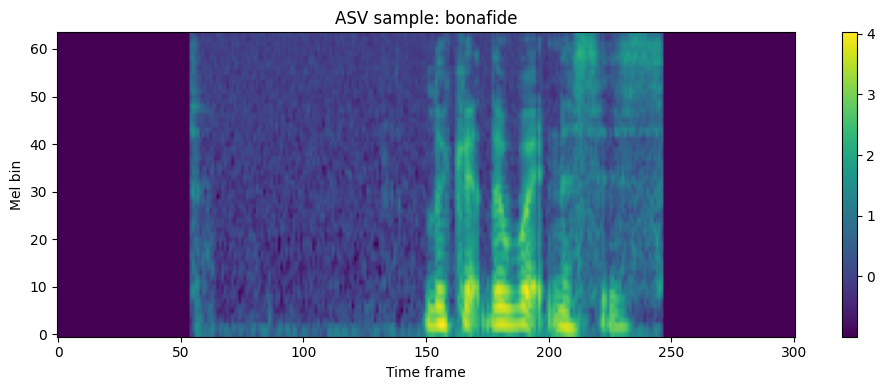

In [ ]:
# ============================================================
# 4. ASVspoof 데이터 불러오기
# ============================================================
ASV_CLASS_NAMES = ["bonafide", "spoof"]


def resolve_asv_splits():
    split_names = get_dataset_split_names(ASV_DATASET)
    print("ASVspoof split:", split_names)

    def choose(candidates):
        for candidate in candidates:
            if candidate in split_names:
                return candidate
        raise RuntimeError(
            f"필요한 split을 찾을 수 없습니다: {candidates}"
        )

    return {
        "train": choose(["train", "training"]),
        "validation": choose(
            ["validation", "dev", "valid"]
        ),
        "test": choose(["test", "eval", "evaluation"]),
    }


ASV_SPLITS = resolve_asv_splits()


def normalize_asv_label(value):
    if isinstance(value, str):
        text = value.strip().lower()

        if text in {
            "bonafide",
            "bona-fide",
            "real",
            "human",
            "0",
        }:
            return 0

        if text in {
            "spoof",
            "fake",
            "synthetic",
            "1",
        }:
            return 1

    value = int(value)

    if value not in (0, 1):
        raise ValueError(
            f"예상하지 못한 ASV label: {value}"
        )

    return value


def collect_asv_features(
    logical_split,
    per_class,
    training=False,
    use_cache=True,
):
    actual_split = ASV_SPLITS[logical_split]

    cache_path = CACHE_DIR / (
        f"asv_{logical_split}_{per_class}_"
        f"{SAMPLE_RATE}_{CLIP_SECONDS}_{N_MELS}.npz"
    )

    if use_cache and cache_path.exists():
        print("✅ 캐시 사용:", cache_path)
        cached = np.load(cache_path)
        return cached["x"], cached["y"]

    print(
        f"\n{logical_split}({actual_split}) 수집 시작 "
        f"- 클래스당 {per_class}개"
    )

    dataset = load_dataset(
        ASV_DATASET,
        split=actual_split,
        streaming=True,
    )

    try:
        dataset = dataset.cast_column(
            "audio",
            Audio(decode=False),
        )
    except Exception:
        pass

    dataset = dataset.shuffle(
        seed=SEED,
        buffer_size=256,
    )

    features = []
    labels = []
    counts = {0: 0, 1: 0}
    skipped = 0

    progress = tqdm(
        total=per_class * 2,
        desc=f"ASV {logical_split}",
    )

    for example in dataset:
        try:
            label = normalize_asv_label(
                example["key"]
            )

            if counts[label] >= per_class:
                continue

            waveform, sr = decode_audio_value(
                example["audio"]
            )

            if len(waveform) < int(0.5 * sr):
                skipped += 1
                continue

            # 중요: 합성음 탐지는 원본에 가까운 신호 사용
            feature = waveform_to_logmel(
                waveform,
                sr,
                training=training,
                apply_augmentation=training,
            )

            features.append(feature)
            labels.append(label)

            counts[label] += 1
            progress.update(1)

            if all(
                counts[c] >= per_class
                for c in (0, 1)
            ):
                break

        except Exception as error:
            skipped += 1

            if skipped <= 5:
                print("건너뜀:", repr(error))

    progress.close()

    if min(counts.values()) == 0:
        raise RuntimeError(
            f"두 클래스를 모두 수집하지 못했습니다: {counts}"
        )

    x = np.stack(features).astype(np.float32)
    y = np.asarray(labels, dtype=np.int32)

    order = np.random.default_rng(SEED).permutation(
        len(y)
    )
    x = x[order]
    y = y[order]

    np.savez_compressed(
        cache_path,
        x=x,
        y=y,
    )

    print(
        "✅ 완료:",
        logical_split,
        x.shape,
        Counter(y),
        "skipped:",
        skipped,
    )

    return x, y


x_train, y_train = collect_asv_features(
    "train",
    ASV_TRAIN_PER_CLASS,
    training=True,
)

x_val, y_val = collect_asv_features(
    "validation",
    ASV_VAL_PER_CLASS,
    training=False,
)

x_test, y_test = collect_asv_features(
    "test",
    ASV_TEST_PER_CLASS,
    training=False,
)

print("\n데이터 크기")
print("train:", x_train.shape, Counter(y_train))
print("val  :", x_val.shape, Counter(y_val))
print("test :", x_test.shape, Counter(y_test))

plot_logmel(
    x_train[0],
    f"ASV sample: {ASV_CLASS_NAMES[int(y_train[0])]}",
)

In [ ]:
# ============================================================
# 5. CNN 모델 구성
# ============================================================
def build_audio_cnn(
    input_shape,
    num_classes,
    model_name,
):
    inputs = tf.keras.Input(
        shape=input_shape,
        name="logmel_input",
    )

    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False,
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.SpatialDropout2D(0.10)(x)

    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(
        128,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(
        192,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    if num_classes == 2:
        outputs = tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="spoof_model_score",
        )(x)
    else:
        outputs = tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            name="class_model_scores",
        )(x)

    return tf.keras.Model(
        inputs,
        outputs,
        name=model_name,
    )

In [ ]:
# ============================================================
# 6. 합성음 탐지 모델 학습
# ============================================================
detector = build_audio_cnn(
    input_shape=x_train.shape[1:],
    num_classes=2,
    model_name="voxshield_spoof_detector",
)

detector.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
    ],
)

detector.summary()

train_ds = make_tf_dataset(
    x_train,
    y_train,
    training=True,
)
val_ds = make_tf_dataset(x_val, y_val)
test_ds = make_tf_dataset(x_test, y_test)

DETECTOR_BEST_PATH = (
    OUTPUT_DIR / "best_voxshield_detector.keras"
)

detector_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(DETECTOR_BEST_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("\n🚀 합성음 탐지 학습 시작")

detector_history = detector.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=detector_callbacks,
)

detector = tf.keras.models.load_model(
    DETECTOR_BEST_PATH
)

print("✅ 최적 detector 로드 완료")

Model: "voxshield_spoof_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel_input (InputLayer)       │ (None, 64, 301, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 301, 32)    │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 301, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 301, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 150, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 32, 150, 32)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 150, 64)    │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 150, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 150, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 75, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 75, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 37, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 37, 192)     │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 37, 192)     │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 37, 192)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 340,129 (1.30 MB)

 Trainable params: 339,297 (1.29 MB)

 Non-trainable params: 832 (3.25 KB)


🚀 합성음 탐지 학습 시작
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7658 - auc: 0.8430 - loss: 0.4563 - precision: 0.7518 - recall: 0.7531
Epoch 1: val_auc improved from None to 0.50000, saving model to /content/voxshield_outputs/best_voxshield_detector.keras

Epoch 1: finished saving model to /content/voxshield_outputs/best_voxshield_detector.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8662 - auc: 0.9475 - loss: 0.2953 - precision: 0.8589 - recall: 0.8765 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 3.2340 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9655 - auc: 0.9937 - loss: 0.1007 - precision: 0.9616 - recall: 0.9690
Epoch 2: val_auc did not improve from 0.50000
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9700 - auc: 0.9955 - loss: 0.0854 - precision: 0.9658 - recall: 0.9745 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 3.6928 - val

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8070 - auc: 0.8772 - loss: 0.5809 - precision: 0.8232 - recall: 0.7820

    accuracy: 0.8070
         auc: 0.8772
        loss: 0.5809
   precision: 0.8232
      recall: 0.7820
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
              precision    recall  f1-score   support

    bonafide     0.7924    0.8320    0.8117       500
       spoof     0.8232    0.7820    0.8021       500

    accuracy                         0.8070      1000
   macro avg     0.8078    0.8070    0.8069      1000
weighted avg     0.8078    0.8070    0.8069      1000



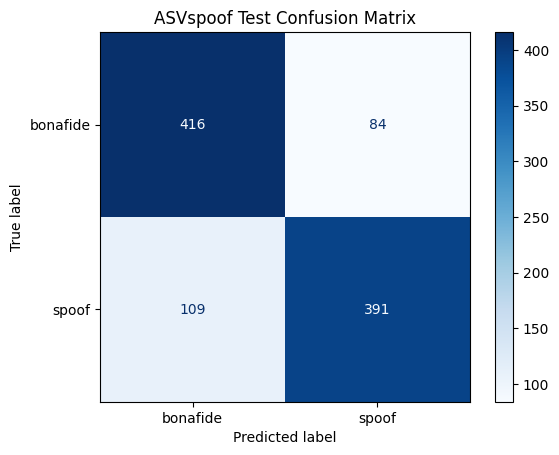

ROC-AUC: 0.8767
Approx. EER: 19.60%
EER threshold: 0.4189


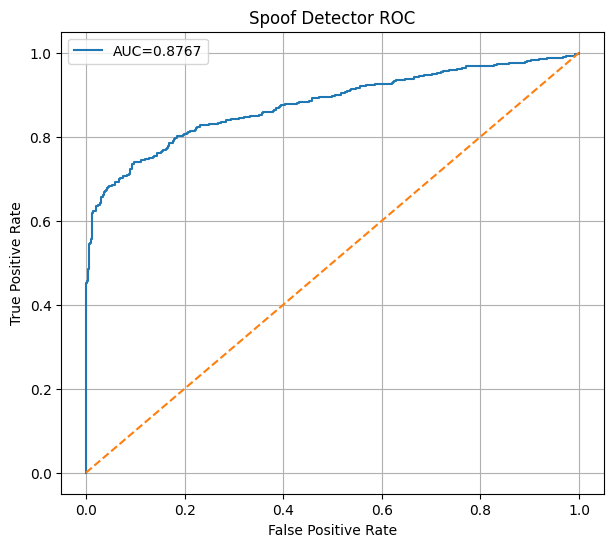

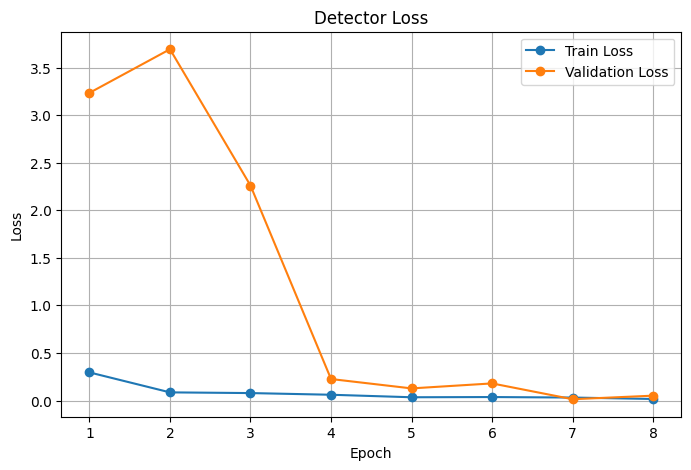

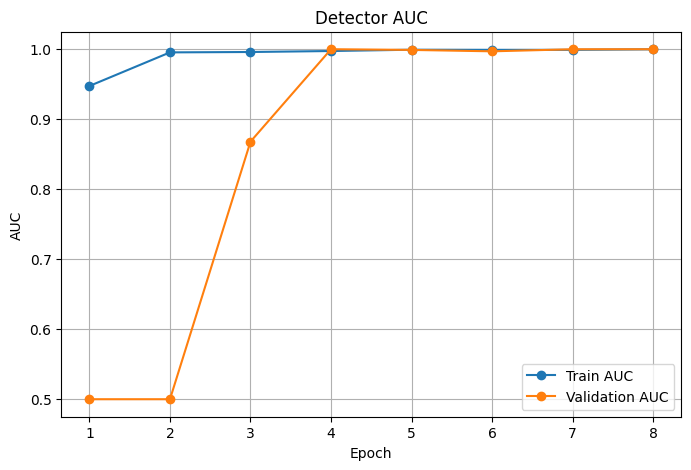

✅ detector 저장 완료


In [ ]:
# ============================================================
# 7. 합성음 탐지 평가 및 저장
# ============================================================
test_metrics = detector.evaluate(
    test_ds,
    verbose=1,
    return_dict=True,
)

print("\n" + "=" * 72)
for name, value in test_metrics.items():
    print(f"{name:>12}: {value:.4f}")
print("=" * 72)

spoof_scores = detector.predict(
    test_ds,
    verbose=1,
).reshape(-1)

predicted_labels = (
    spoof_scores >= 0.5
).astype(np.int32)

print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=ASV_CLASS_NAMES,
        digits=4,
    )
)

cm = confusion_matrix(
    y_test,
    predicted_labels,
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ASV_CLASS_NAMES,
).plot(
    cmap="Blues",
    values_format="d",
)

plt.title("ASVspoof Test Confusion Matrix")
plt.show()

auc_value = roc_auc_score(
    y_test,
    spoof_scores,
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    spoof_scores,
)
fnr = 1.0 - tpr

eer_index = np.nanargmin(
    np.abs(fnr - fpr)
)
eer = (
    fpr[eer_index] + fnr[eer_index]
) / 2.0
eer_threshold = thresholds[eer_index]

print(f"ROC-AUC: {auc_value:.4f}")
print(f"Approx. EER: {eer * 100:.2f}%")
print(f"EER threshold: {eer_threshold:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc_value:.4f}",
)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spoof Detector ROC")
plt.grid(True)
plt.legend()
plt.show()

history = detector_history.history
epochs_ran = range(
    1,
    len(history["loss"]) + 1,
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_ran,
    history["loss"],
    marker="o",
    label="Train Loss",
)
plt.plot(
    epochs_ran,
    history["val_loss"],
    marker="o",
    label="Validation Loss",
)
plt.title("Detector Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_ran,
    history["auc"],
    marker="o",
    label="Train AUC",
)
plt.plot(
    epochs_ran,
    history["val_auc"],
    marker="o",
    label="Validation AUC",
)
plt.title("Detector AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.grid(True)
plt.legend()
plt.show()

DETECTOR_MODEL_PATH = (
    OUTPUT_DIR / "voxshield_spoof_detector.keras"
)
DETECTOR_LABEL_PATH = (
    OUTPUT_DIR / "voxshield_spoof_labels.json"
)
PREPROCESS_PATH = (
    OUTPUT_DIR / "voxshield_audio_preprocess.json"
)

detector.save(DETECTOR_MODEL_PATH)

with open(
    DETECTOR_LABEL_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "0": "bonafide",
            "1": "spoof",
            "note": (
                "출력값은 spoof 클래스의 모델 점수입니다. "
                "현실의 확정 확률로 해석하지 마세요."
            ),
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    PREPROCESS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "sample_rate": SAMPLE_RATE,
            "clip_seconds": CLIP_SECONDS,
            "n_mels": N_MELS,
            "n_fft": N_FFT,
            "win_length": WIN_LENGTH,
            "hop_length": HOP_LENGTH,
            "time_frames": TIME_FRAMES,
            "detector_path": (
                "원본에 가까운 오디오 사용"
            ),
            "accent_path": (
                "Noise Focus 보정 오디오 사용"
            ),
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("✅ detector 저장 완료")

## 선택 사항: 억양/L1 영향 발화 패턴 모델

이 데이터셋에는 직접적인 `Indian English`, `British English` 라벨이 없습니다.  
따라서 아래 모델은 `native_language`를 사용하여 **L1 영향 발화 패턴 유사도**를 학습합니다.

- `country`를 국적 추정 라벨로 사용하지 않습니다.
- 출력은 화자의 국적·출생지·신원을 뜻하지 않습니다.
- 사기 위험 점수와 억양 결과를 결합하지 않습니다.

In [ ]:
# ============================================================
# 8. 억양/L1 패턴 메타데이터 및 화자 단위 분할
# ============================================================
accent_model = None
accent_class_names = []

if RUN_ACCENT_MODEL:
    def normalize_text_label(value):
        if value is None:
            return ""
        return " ".join(
            str(value).strip().lower().split()
        )

    metadata_columns = [
        "native_language",
        "speakerid",
        "file_exists",
        "file_missing?",
    ]

    try:
        accent_meta = load_dataset(
            ACCENT_DATASET,
            split="train",
            streaming=True,
            columns=metadata_columns,
        )
    except Exception:
        accent_meta = load_dataset(
            ACCENT_DATASET,
            split="train",
            streaming=True,
        )

        try:
            accent_meta = accent_meta.select_columns(
                metadata_columns
            )
        except Exception:
            pass

    metadata_rows = []
    label_counts = Counter()

    for example in tqdm(
        accent_meta,
        desc="Accent metadata",
    ):
        label = normalize_text_label(
            example.get("native_language")
        )
        speaker_id = str(
            example.get("speakerid", "")
        )

        exists = example.get(
            "file_exists",
            True,
        )
        missing = example.get(
            "file_missing?",
            False,
        )

        if (
            not label
            or not speaker_id
            or not exists
            or missing
        ):
            continue

        metadata_rows.append(
            {
                "speakerid": speaker_id,
                "label": label,
            }
        )
        label_counts[label] += 1

    print("\n상위 native_language 클래스")

    for label, count in label_counts.most_common(20):
        print(f"{label:>25}: {count}")

    if ACCENT_TARGETS:
        requested = [
            normalize_text_label(item)
            for item in ACCENT_TARGETS
        ]

        accent_class_names = [
            item
            for item in requested
            if label_counts[item]
            >= ACCENT_MIN_CLASS_COUNT
        ]
    else:
        accent_class_names = [
            label
            for label, count
            in label_counts.most_common()
            if count >= ACCENT_MIN_CLASS_COUNT
        ][:ACCENT_NUM_CLASSES]

    if len(accent_class_names) < 2:
        raise RuntimeError(
            "사용 가능한 native_language 클래스가 "
            "2개 미만입니다."
        )

    print(
        "\n선택된 클래스:",
        accent_class_names,
    )

    rows_by_label = defaultdict(list)

    for row in metadata_rows:
        if row["label"] in accent_class_names:
            rows_by_label[
                row["label"]
            ].append(row["speakerid"])

    rng = random.Random(SEED)
    speaker_to_info = {}

    for label in accent_class_names:
        speaker_ids = list(
            dict.fromkeys(rows_by_label[label])
        )
        rng.shuffle(speaker_ids)

        selected_count = min(
            ACCENT_MAX_PER_CLASS,
            len(speaker_ids),
        )
        speaker_ids = speaker_ids[
            :selected_count
        ]

        train_end = max(
            1,
            int(selected_count * 0.70),
        )
        val_end = max(
            train_end + 1,
            int(selected_count * 0.85),
        )

        split_ids = {
            "train": speaker_ids[:train_end],
            "validation": speaker_ids[
                train_end:val_end
            ],
            "test": speaker_ids[val_end:],
        }

        for split_name, ids in split_ids.items():
            for speaker_id in ids:
                speaker_to_info[speaker_id] = {
                    "split": split_name,
                    "label": label,
                }

    print(
        "선택 화자 수:",
        len(speaker_to_info),
    )
else:
    print(
        "RUN_ACCENT_MODEL=False → "
        "억양 모델을 건너뜁니다."
    )

README.md:   0%|          | 0.00/966 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Accent metadata: 0it [00:00, ?it/s]


상위 native_language 클래스
                  english: 579
                  spanish: 162
                   arabic: 102
                 mandarin: 65
                   french: 63
                   korean: 52
               portuguese: 48
                  russian: 48
                    dutch: 47
                  turkish: 37
                   german: 36
                   polish: 34
                  italian: 33
                 japanese: 27
               macedonian: 26
                cantonese: 23
                    farsi: 23
               vietnamese: 22
                  amharic: 20
                 romanian: 20

선택된 클래스: ['english', 'spanish', 'arabic', 'mandarin', 'french']
선택 화자 수: 200


In [ ]:
!pip -q install resampy==0.4.3

import resampy

print("✅ resampy 설치 완료:", resampy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.9 MB/s eta 0:00:00
✅ resampy 설치 완료: 0.4.3


In [ ]:
# ============================================================
# resampy를 사용하지 않는 리샘플링 함수
# 기존 resample_audio 함수를 덮어씁니다.
# ============================================================
from math import gcd

import numpy as np
from scipy.signal import resample_poly


def resample_audio(
    waveform,
    original_sr,
    target_sr=SAMPLE_RATE,
):
    """
    scipy.signal.resample_poly를 사용해 오디오를 리샘플링합니다.
    resampy와 librosa.resample을 사용하지 않습니다.
    """

    x = to_mono_float32(waveform)

    original_sr = int(original_sr)
    target_sr = int(target_sr)

    if original_sr <= 0 or target_sr <= 0:
        raise ValueError(
            f"잘못된 샘플링 레이트: "
            f"{original_sr} -> {target_sr}"
        )

    if original_sr == target_sr:
        return np.asarray(
            x,
            dtype=np.float32,
        )

    common_divisor = gcd(
        original_sr,
        target_sr,
    )

    up = target_sr // common_divisor
    down = original_sr // common_divisor

    resampled = resample_poly(
        x,
        up=up,
        down=down,
    )

    return np.asarray(
        resampled,
        dtype=np.float32,
    )


print("✅ resampy 없는 resample_audio 함수 적용 완료")

✅ resampy 없는 resample_audio 함수 적용 완료


In [ ]:
test_audio = np.zeros(
    44_100,
    dtype=np.float32,
)

test_output = resample_audio(
    test_audio,
    original_sr=44_100,
    target_sr=16_000,
)

print("변환 전:", len(test_audio))
print("변환 후:", len(test_output))

변환 전: 44100
변환 후: 16000


In [ ]:
# ============================================================
# 9. Noise Focus를 적용한 억양 특징 추출
# resampy 자동 설치 포함
# ============================================================
import importlib
import importlib.util
import subprocess
import sys

import numpy as np
from tqdm.auto import tqdm
from collections import Counter


# ------------------------------------------------------------
# 9-1. resampy 자동 설치 및 확인
# ------------------------------------------------------------
if importlib.util.find_spec("resampy") is None:
    print("📦 resampy가 없어 자동으로 설치합니다...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "resampy==0.4.3",
        ]
    )

    importlib.invalidate_caches()

import resampy

print("✅ resampy 준비 완료:", resampy.__version__)


# ------------------------------------------------------------
# 9-2. 억양 오디오 특징 추출
# ------------------------------------------------------------
if RUN_ACCENT_MODEL:

    # 클래스 이름 → 숫자 라벨
    label_to_id = {
        label: index
        for index, label in enumerate(accent_class_names)
    }

    accent_features = {
        "train": [],
        "validation": [],
        "test": [],
    }

    accent_labels = {
        "train": [],
        "validation": [],
        "test": [],
    }

    # 8번 셀에서 선택된 화자 ID
    remaining_speakers = set(
        speaker_to_info.keys()
    )

    print("전체 추출 대상 화자:", len(remaining_speakers))
    print("선택된 클래스:", accent_class_names)

    # Hugging Face 데이터셋 전체를 저장하지 않고 스트리밍
    accent_stream = load_dataset(
        ACCENT_DATASET,
        split="train",
        streaming=True,
    )

    progress = tqdm(
        total=len(remaining_speakers),
        desc="Accent audio",
    )

    skipped = 0
    successful = 0

    for example in accent_stream:

        speaker_id = str(
            example.get("speakerid", "")
        )

        # 이번 학습 대상으로 선택되지 않은 화자는 건너뜀
        if speaker_id not in remaining_speakers:
            continue

        info = speaker_to_info[speaker_id]

        split_name = info["split"]
        label_name = info["label"]

        try:
            # Hugging Face 오디오 디코딩
            waveform, sr = decode_audio_value(
                example["audio"]
            )

            # 너무 짧은 음성은 제외
            if len(waveform) < int(0.5 * sr):
                raise ValueError(
                    "음성이 0.5초보다 짧습니다."
                )

            # 억양 분석용 Noise Focus 적용
            focused_waveform = focus_on_speech(
                waveform,
                sr,
            )

            # Log-Mel Spectrogram 특징 생성
            feature = waveform_to_logmel(
                focused_waveform,
                SAMPLE_RATE,
                training=(split_name == "train"),
                apply_augmentation=False,
            )

            accent_features[
                split_name
            ].append(feature)

            accent_labels[
                split_name
            ].append(
                label_to_id[label_name]
            )

            successful += 1

        except Exception as error:

            skipped += 1

            # 오류가 너무 많이 출력되지 않도록 처음 10개만 표시
            if skipped <= 10:
                print(
                    "\n⚠️ Accent 건너뜀:",
                    speaker_id,
                    repr(error),
                )

        finally:
            # 성공 여부와 관계없이 해당 화자는 처리 완료
            remaining_speakers.discard(
                speaker_id
            )

            progress.update(1)

        # 목표 화자를 모두 처리했다면 스트리밍 종료
        if not remaining_speakers:
            break

    progress.close()

    print("\n" + "=" * 70)
    print("특징 추출 성공:", successful)
    print("건너뛴 음성:", skipped)
    print("찾지 못한 화자:", len(remaining_speakers))
    print("=" * 70)

    if successful == 0:
        raise RuntimeError(
            "억양 특징을 하나도 추출하지 못했습니다. "
            "위 오류 메시지를 확인하세요."
        )


    # --------------------------------------------------------
    # 9-3. 리스트를 NumPy 배열로 변환
    # --------------------------------------------------------
    def stack_accent_split(split_name):

        split_features = accent_features[
            split_name
        ]

        split_labels = accent_labels[
            split_name
        ]

        if not split_features:
            raise RuntimeError(
                f"{split_name} 데이터가 비어 있습니다. "
                "8번 셀의 화자 분할 설정을 확인하세요."
            )

        x = np.stack(
            split_features
        ).astype(np.float32)

        y = np.asarray(
            split_labels,
            dtype=np.int32,
        )

        # 데이터 순서 섞기
        random_order = np.random.default_rng(
            SEED
        ).permutation(len(y))

        x = x[random_order]
        y = y[random_order]

        return x, y


    ax_train, ay_train = stack_accent_split(
        "train"
    )

    ax_val, ay_val = stack_accent_split(
        "validation"
    )

    ax_test, ay_test = stack_accent_split(
        "test"
    )


    # --------------------------------------------------------
    # 9-4. 결과 확인
    # --------------------------------------------------------
    print("\n✅ 억양 특징 추출 완료")

    print(
        "Accent train:",
        ax_train.shape,
        Counter(ay_train),
    )

    print(
        "Accent val  :",
        ax_val.shape,
        Counter(ay_val),
    )

    print(
        "Accent test :",
        ax_test.shape,
        Counter(ay_test),
    )

    print("\n클래스 번호:")

    for label_name, label_id in label_to_id.items():
        print(
            f"{label_id}: {label_name}-L1-like"
        )

else:
    print(
        "RUN_ACCENT_MODEL=False입니다. "
        "True로 변경한 뒤 다시 실행하세요."
    )

✅ resampy 준비 완료: 0.4.3
전체 추출 대상 화자: 200
선택된 클래스: ['english', 'spanish', 'arabic', 'mandarin', 'french']


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Accent audio:   0%|          | 0/200 [00:00<?, ?it/s]


특징 추출 성공: 200
건너뛴 음성: 0
찾지 못한 화자: 0

✅ 억양 특징 추출 완료
Accent train: (140, 64, 301, 1) Counter({np.int32(3): 28, np.int32(2): 28, np.int32(4): 28, np.int32(1): 28, np.int32(0): 28})
Accent val  : (30, 64, 301, 1) Counter({np.int32(1): 6, np.int32(4): 6, np.int32(0): 6, np.int32(3): 6, np.int32(2): 6})
Accent test : (30, 64, 301, 1) Counter({np.int32(1): 6, np.int32(4): 6, np.int32(0): 6, np.int32(3): 6, np.int32(2): 6})

클래스 번호:
0: english-L1-like
1: spanish-L1-like
2: arabic-L1-like
3: mandarin-L1-like
4: french-L1-like


In [ ]:
# ============================================================
# 10. 억양/L1 패턴 모델 학습·평가·저장
# ============================================================
if RUN_ACCENT_MODEL:
    accent_model = build_audio_cnn(
        input_shape=ax_train.shape[1:],
        num_classes=len(accent_class_names),
        model_name=(
            "voxshield_l1_pattern_classifier"
        ),
    )

    accent_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    accent_train_ds = make_tf_dataset(
        ax_train,
        ay_train,
        training=True,
    )
    accent_val_ds = make_tf_dataset(
        ax_val,
        ay_val,
    )
    accent_test_ds = make_tf_dataset(
        ax_test,
        ay_test,
    )

    ACCENT_BEST_PATH = (
        OUTPUT_DIR /
        "best_voxshield_l1_pattern.keras"
    )

    accent_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ACCENT_BEST_PATH),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    print("\n🚀 억양 패턴 학습 시작")

    accent_history = accent_model.fit(
        accent_train_ds,
        validation_data=accent_val_ds,
        epochs=EPOCHS,
        callbacks=accent_callbacks,
    )

    accent_model = tf.keras.models.load_model(
        ACCENT_BEST_PATH
    )

    accent_probabilities = accent_model.predict(
        accent_test_ds,
        verbose=1,
    )
    accent_predictions = np.argmax(
        accent_probabilities,
        axis=1,
    )

    safe_class_names = [
        f"{name}-L1-like"
        for name in accent_class_names
    ]

    print(
        classification_report(
            ay_test,
            accent_predictions,
            labels=list(
                range(len(accent_class_names))
            ),
            target_names=safe_class_names,
            digits=4,
            zero_division=0,
        )
    )

    accent_cm = confusion_matrix(
        ay_test,
        accent_predictions,
        labels=list(
            range(len(accent_class_names))
        ),
    )

    ConfusionMatrixDisplay(
        confusion_matrix=accent_cm,
        display_labels=safe_class_names,
    ).plot(
        cmap="Blues",
        values_format="d",
        xticks_rotation=45,
    )

    plt.title(
        "L1-influenced Speech Pattern"
    )
    plt.tight_layout()
    plt.show()

    ACCENT_MODEL_PATH = (
        OUTPUT_DIR /
        "voxshield_l1_pattern.keras"
    )
    ACCENT_LABEL_PATH = (
        OUTPUT_DIR /
        "voxshield_l1_pattern_labels.json"
    )

    accent_model.save(
        ACCENT_MODEL_PATH
    )

    with open(
        ACCENT_LABEL_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                str(index): (
                    f"{name}-L1-like"
                )
                for index, name
                in enumerate(accent_class_names)
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("✅ 억양 패턴 모델 저장 완료")
else:
    print(
        "RUN_ACCENT_MODEL=False → "
        "억양 학습을 건너뜁니다."
    )

RUN_ACCENT_MODEL=False → 억양 학습을 건너뜁니다.


In [ ]:
# ============================================================
# 11. Colab 브라우저 마이크 녹음
# ============================================================
RECORDING_JAVASCRIPT = r"""
async function voxshieldRecord(seconds) {
  const container = document.createElement("div");
  container.style.padding = "18px";
  container.style.border = "1px solid #d0d7de";
  container.style.borderRadius = "14px";
  container.style.maxWidth = "620px";
  container.style.fontFamily = "Arial, sans-serif";
  container.style.background = "#ffffff";

  const title = document.createElement("div");
  title.innerText = "🎙 VoxShield 음성 녹음";
  title.style.fontWeight = "700";
  title.style.fontSize = "18px";
  title.style.marginBottom = "8px";

  const notice = document.createElement("div");
  notice.innerText =
    "한 명이 자연스럽게 말해주세요. 원본 보존을 위해 브라우저 소음 제거는 끄고, Python에서 분석 목적에 따라 분기합니다.";
  notice.style.fontSize = "13px";
  notice.style.color = "#57606a";
  notice.style.marginBottom = "14px";

  const status = document.createElement("div");
  status.innerText = "마이크 권한을 요청합니다...";
  status.style.marginBottom = "10px";

  const progressOuter = document.createElement("div");
  progressOuter.style.height = "12px";
  progressOuter.style.background = "#eaeef2";
  progressOuter.style.borderRadius = "999px";
  progressOuter.style.overflow = "hidden";

  const progressInner = document.createElement("div");
  progressInner.style.width = "0%";
  progressInner.style.height = "100%";
  progressInner.style.background = "#cf222e";
  progressInner.style.transition = "width 0.1s linear";

  progressOuter.appendChild(progressInner);
  container.appendChild(title);
  container.appendChild(notice);
  container.appendChild(status);
  container.appendChild(progressOuter);
  document.body.appendChild(container);

  let stream;

  try {
    stream = await navigator.mediaDevices.getUserMedia({
      audio: {
        channelCount: 1,
        echoCancellation: false,
        noiseSuppression: false,
        autoGainControl: false
      }
    });
  } catch (error) {
    status.innerText =
      "마이크 권한을 사용할 수 없습니다: " + error;
    throw error;
  }

  const mimeCandidates = [
    "audio/webm;codecs=opus",
    "audio/webm",
    "audio/ogg;codecs=opus"
  ];

  let selectedMime = "";

  for (const candidate of mimeCandidates) {
    if (MediaRecorder.isTypeSupported(candidate)) {
      selectedMime = candidate;
      break;
    }
  }

  const options = selectedMime
    ? { mimeType: selectedMime }
    : {};

  const recorder = new MediaRecorder(
    stream,
    options
  );
  const chunks = [];

  recorder.ondataavailable = event => {
    if (event.data.size > 0) {
      chunks.push(event.data);
    }
  };

  const stopped = new Promise(resolve => {
    recorder.onstop = resolve;
  });

  recorder.start(100);
  status.innerText =
    `● 녹음 중: ${seconds}초 동안 자연스럽게 말해주세요.`;

  const startedAt = Date.now();

  const timer = setInterval(() => {
    const elapsed =
      (Date.now() - startedAt) / 1000;
    const ratio = Math.min(
      elapsed / seconds,
      1
    );

    progressInner.style.width =
      `${ratio * 100}%`;

    status.innerText =
      `● 녹음 중 ${elapsed.toFixed(1)} / ${seconds}초`;
  }, 100);

  await new Promise(resolve => {
    setTimeout(resolve, seconds * 1000);
  });

  clearInterval(timer);
  recorder.stop();
  await stopped;

  stream.getTracks().forEach(
    track => track.stop()
  );

  status.innerText =
    "✅ 녹음 완료. Python으로 전달 중...";
  progressInner.style.width = "100%";
  progressInner.style.background = "#1a7f37";

  const blob = new Blob(
    chunks,
    {
      type: selectedMime || "audio/webm"
    }
  );

  const dataUrl = await new Promise(
    (resolve, reject) => {
      const reader = new FileReader();

      reader.onloadend = () => {
        resolve(reader.result);
      };

      reader.onerror = reject;
      reader.readAsDataURL(blob);
    }
  );

  setTimeout(() => {
    container.remove();
  }, 1500);

  return dataUrl;
}
"""

display(
    Javascript(RECORDING_JAVASCRIPT)
)

print("✅ 마이크 녹음 함수 준비 완료")

<IPython.core.display.Javascript object>

✅ 마이크 녹음 함수 준비 완료


In [ ]:
# ============================================================
# 12. 녹음 저장 및 변환
# ============================================================
def record_microphone(
    seconds=RECORD_SECONDS,
    output_stem="voxshield_recording",
):
    if seconds < 3:
        raise ValueError(
            "녹음 시간은 최소 3초 이상이어야 합니다."
        )

    print(
        f"🎙 {seconds}초 녹음을 시작합니다. "
        "브라우저의 마이크 권한을 허용하세요."
    )

    data_url = eval_js(
        f"voxshieldRecord({int(seconds)})"
    )

    if (
        not isinstance(data_url, str)
        or "," not in data_url
    ):
        raise RuntimeError(
            "브라우저에서 녹음 데이터를 받지 못했습니다."
        )

    header, encoded = data_url.split(",", 1)
    match = re.match(
        r"data:([^;]+);base64",
        header,
    )
    mime_type = (
        match.group(1)
        if match
        else "audio/webm"
    )

    extension = (
        ".ogg"
        if "ogg" in mime_type
        else ".webm"
    )

    browser_path = (
        RECORD_DIR /
        f"{output_stem}{extension}"
    )
    wav_path = (
        RECORD_DIR /
        f"{output_stem}_raw.wav"
    )

    with open(browser_path, "wb") as file:
        file.write(
            base64.b64decode(encoded)
        )

    command = [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(browser_path),
        "-ac",
        "1",
        "-ar",
        str(SAMPLE_RATE),
        "-c:a",
        "pcm_s16le",
        str(wav_path),
    ]

    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "ffmpeg 변환에 실패했습니다: "
            + completed.stderr
        )

    print("✅ WAV 저장:", wav_path)
    return wav_path

In [ ]:
# ============================================================
# 13. 녹음 분석
# ============================================================
def analyze_recording(
    wav_path,
    save_focused_audio=True,
):
    raw_waveform, raw_sr = sf.read(
        str(wav_path),
        always_2d=False,
    )
    raw_waveform = to_mono_float32(
        raw_waveform
    )

    quality = quality_report(
        raw_waveform,
        raw_sr,
    )

    # --------------------------------------------------------
    # 1) 합성음 탐지: 원본에 가까운 음성 사용
    # --------------------------------------------------------
    raw_feature = waveform_to_logmel(
        raw_waveform,
        raw_sr,
        training=False,
        apply_augmentation=False,
    )

    spoof_score = float(
        detector.predict(
            raw_feature[np.newaxis, ...],
            verbose=0,
        )[0][0]
    )
    human_score = 1.0 - spoof_score

    speech_seconds = float(
        quality["speech_seconds"]
    )

    if speech_seconds < MIN_SPEECH_FOR_SPOOF:
        spoof_decision = (
            "판단 보류: 유효 발화 길이 부족"
        )
    elif quality["quality"] == "낮음":
        spoof_decision = (
            "낮은 신뢰도: 녹음 품질 확인 필요"
        )
    elif spoof_score >= 0.5:
        spoof_decision = "합성·변조 의심"
    else:
        spoof_decision = (
            "사람 음성 가능성이 높음"
        )

    # --------------------------------------------------------
    # 2) 억양 분석: Noise Focus 보정본 사용
    # --------------------------------------------------------
    focused_waveform = focus_on_speech(
        raw_waveform,
        raw_sr,
    )

    focused_path = (
        RECORD_DIR /
        f"{pathlib.Path(wav_path).stem}_focused.wav"
    )

    if save_focused_audio:
        sf.write(
            focused_path,
            focused_waveform,
            SAMPLE_RATE,
        )

    result = {
        "audio_quality": quality,
        "synthetic_voice": {
            "human_model_score": round(
                human_score,
                4,
            ),
            "spoof_model_score": round(
                spoof_score,
                4,
            ),
            "decision": spoof_decision,
            "input": (
                "원본에 가까운 녹음 사용"
            ),
        },
        "accent_pattern": {
            "status": (
                "모델을 학습하지 않음"
            ),
            "input": (
                "Noise Focus 보정 음성 사용"
            ),
        },
        "files": {
            "raw_wav": str(wav_path),
            "focused_wav": str(
                focused_path
            ),
        },
        "limitations": [
            (
                "표시된 값은 모델 점수이며 "
                "현실의 확정 확률이 아닙니다."
            ),
            (
                "Noise Focus는 배경 소음을 줄이지만 "
                "겹친 여러 화자 중 특정 한 명을 "
                "완벽하게 분리하지 않습니다."
            ),
            (
                "억양 결과는 국적·출생지·신원 또는 "
                "사기 여부를 의미하지 않습니다."
            ),
            (
                "수사·신원 확인·금융 의사결정의 "
                "단독 근거로 사용하지 마세요."
            ),
        ],
    }

    if RUN_ACCENT_MODEL and accent_model is not None:
        if speech_seconds < MIN_SPEECH_FOR_ACCENT:
            result["accent_pattern"] = {
                "status": (
                    "판단 보류: 억양 분석에 "
                    "필요한 발화 길이 부족"
                ),
                "input": (
                    "Noise Focus 보정 음성 사용"
                ),
            }
        else:
            accent_feature = waveform_to_logmel(
                focused_waveform,
                SAMPLE_RATE,
                training=False,
                apply_augmentation=False,
            )

            probabilities = accent_model.predict(
                accent_feature[
                    np.newaxis,
                    ...
                ],
                verbose=0,
            )[0]

            top_indices = np.argsort(
                probabilities
            )[::-1][:3]

            top_matches = [
                {
                    "label": (
                        f"{accent_class_names[index]}"
                        "-L1-like"
                    ),
                    "model_score": round(
                        float(
                            probabilities[index]
                        ),
                        4,
                    ),
                }
                for index in top_indices
            ]

            highest_score = float(
                probabilities[
                    top_indices[0]
                ]
            )

            result["accent_pattern"] = {
                "status": (
                    "불확실"
                    if highest_score
                    < ACCENT_UNCERTAIN_THRESHOLD
                    else "결과 제공"
                ),
                "top_matches": top_matches,
                "input": (
                    "Noise Focus 보정 음성 사용"
                ),
                "interpretation": (
                    "학습 데이터의 native_language "
                    "기반 발화 패턴과의 유사도입니다. "
                    "국적·출생지·신원을 의미하지 않습니다."
                ),
            }

    return result

In [ ]:
# ============================================================
# 14. 리포트 UI
# ============================================================
def score_bar(label, score, color):
    percent = max(
        0.0,
        min(float(score), 1.0),
    ) * 100.0

    return f"""
    <div style="margin:10px 0;">
      <div style="
        display:flex;
        justify-content:space-between;
        font-size:14px;
        margin-bottom:5px;
      ">
        <span>{html.escape(label)}</span>
        <strong>{percent:.1f}%</strong>
      </div>
      <div style="
        background:#eaeef2;
        border-radius:999px;
        height:12px;
        overflow:hidden;
      ">
        <div style="
          width:{percent:.1f}%;
          background:{color};
          height:100%;
        "></div>
      </div>
    </div>
    """


def display_analysis_report(result):
    quality = result["audio_quality"]
    synthetic = result["synthetic_voice"]
    accent = result["accent_pattern"]

    accent_html = (
        "<p>억양 패턴 모델을 실행하지 않았습니다.</p>"
    )

    if accent.get("top_matches"):
        rows = []

        for item in accent["top_matches"]:
            rows.append(
                score_bar(
                    item["label"],
                    item["model_score"],
                    "#8250df",
                )
            )

        accent_html = "".join(rows)

    limitations = "".join(
        f"<li>{html.escape(item)}</li>"
        for item in result["limitations"]
    )

    report_html = f"""
    <div style="
      font-family:Arial,sans-serif;
      max-width:920px;
      border:1px solid #d0d7de;
      border-radius:18px;
      padding:24px;
      background:#ffffff;
      box-shadow:0 8px 30px rgba(0,0,0,0.06);
    ">
      <h2 style="margin-top:0;">
        VoxShield 분석 리포트
      </h2>

      <div style="
        display:grid;
        grid-template-columns:repeat(
          auto-fit,
          minmax(260px,1fr)
        );
        gap:16px;
      ">
        <section style="
          border:1px solid #d8dee4;
          border-radius:14px;
          padding:18px;
        ">
          <h3 style="margin-top:0;">음성 품질</h3>
          <p>전체 길이:
            <strong>{quality["duration_seconds"]}초</strong>
          </p>
          <p>유효 발화:
            <strong>{quality["speech_seconds"]}초</strong>
          </p>
          <p>추정 SNR:
            <strong>{quality["estimated_snr_db"]} dB</strong>
          </p>
          <p>품질:
            <strong>{html.escape(quality["quality"])}</strong>
          </p>
          <p style="font-size:12px;color:#57606a;">
            다중 화자 여부는 이 MVP에서 판정하지 않습니다.
          </p>
        </section>

        <section style="
          border:1px solid #d8dee4;
          border-radius:14px;
          padding:18px;
        ">
          <h3 style="margin-top:0;">합성음 탐지</h3>
          {score_bar(
              "사람 음성 모델 점수",
              synthetic["human_model_score"],
              "#1a7f37"
          )}
          {score_bar(
              "합성·변조 모델 점수",
              synthetic["spoof_model_score"],
              "#cf222e"
          )}
          <p>
            <strong>
              {html.escape(synthetic["decision"])}
            </strong>
          </p>
          <p style="font-size:12px;color:#57606a;">
            입력: {html.escape(synthetic["input"])}
          </p>
        </section>

        <section style="
          border:1px solid #d8dee4;
          border-radius:14px;
          padding:18px;
        ">
          <h3 style="margin-top:0;">발화 패턴 분석</h3>
          <p>
            상태:
            <strong>
              {html.escape(accent.get("status",""))}
            </strong>
          </p>
          {accent_html}
          <p style="font-size:12px;color:#57606a;">
            입력: Noise Focus 보정 음성
          </p>
        </section>
      </div>

      <section style="
        margin-top:16px;
        background:#fff8c5;
        border:1px solid #d4a72c;
        border-radius:14px;
        padding:16px;
      ">
        <strong>해석상의 제한</strong>
        <ul style="margin-bottom:0;">
          {limitations}
        </ul>
      </section>
    </div>
    """

    display(HTML(report_html))

In [ ]:
# ============================================================
# 15. 음성 파일 업로드 후 즉시 분석
# 마이크 녹음 대신 WAV/MP3/M4A/FLAC/OGG/WEBM 업로드
# ============================================================
import json
import pathlib
import subprocess

from google.colab import files
from IPython.display import display
from IPython.display import Audio as IPythonAudio


def convert_to_standard_wav(
    input_path,
    output_path,
):
    """
    업로드된 음성을 모델 입력 형식으로 변환합니다.

    출력 형식:
    - WAV
    - mono
    - 16 kHz
    - PCM 16-bit
    """

    command = [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(input_path),
        "-ac",
        "1",
        "-ar",
        str(SAMPLE_RATE),
        "-c:a",
        "pcm_s16le",
        str(output_path),
    ]

    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "음성 변환에 실패했습니다.\n"
            + completed.stderr
        )

    return output_path


def run_upload_demo(
    play_audio=True,
):
    print(
        "🎧 분석할 음성 파일을 선택하세요.\n"
        "지원 형식: WAV, MP3, M4A, FLAC, OGG, WEBM"
    )

    uploaded = files.upload()

    if not uploaded:
        print("⚠️ 업로드된 파일이 없습니다.")
        return None

    RECORD_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    all_results = {}

    for uploaded_name, uploaded_bytes in uploaded.items():

        safe_name = pathlib.Path(
            uploaded_name
        ).name

        original_path = (
            RECORD_DIR /
            safe_name
        )

        with open(
            original_path,
            "wb",
        ) as output_file:
            output_file.write(
                uploaded_bytes
            )

        standardized_path = (
            RECORD_DIR /
            f"{original_path.stem}_standardized.wav"
        )

        print(
            f"\n🔄 음성을 변환하고 있습니다: "
            f"{safe_name}"
        )

        convert_to_standard_wav(
            original_path,
            standardized_path,
        )

        print(
            "✅ 변환 완료:",
            standardized_path,
        )

        print("🔍 음성을 분석하고 있습니다...")

        result = analyze_recording(
            standardized_path
        )

        if play_audio:
            print("\n원본 기준 음성")

            display(
                IPythonAudio(
                    filename=str(
                        standardized_path
                    )
                )
            )

            focused_path = result[
                "files"
            ]["focused_wav"]

            print("\nNoise Focus 보정본")

            display(
                IPythonAudio(
                    filename=str(
                        focused_path
                    )
                )
            )

        display_analysis_report(
            result
        )

        print("\nJSON 결과")

        print(
            json.dumps(
                result,
                ensure_ascii=False,
                indent=2,
            )
        )

        all_results[safe_name] = result

    return all_results


# 파일 선택창 자동 실행
upload_results = run_upload_demo()

🎧 분석할 음성 파일을 선택하세요.
지원 형식: WAV, MP3, M4A, FLAC, OGG, WEBM


⚠️ 업로드된 파일이 없습니다.


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

drive_models = list(
    Path("/content/drive/MyDrive").rglob("*.keras")
)

print("Drive에서 찾은 모델:")

for path in drive_models:
    print(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive에서 찾은 모델:
/content/drive/MyDrive/flower_mobilenet_v2.keras
/content/drive/MyDrive/VoxShield/models/best_voxshield_detector.keras
/content/drive/MyDrive/VoxShield/models/voxshield_spoof_detector.keras


In [ ]:
import zipfile
from pathlib import Path
from google.colab import files, drive

# Drive 연결
drive.mount("/content/drive", force_remount=False)

# 컴퓨터에서 ZIP을 Colab으로 업로드
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("업로드된 파일이 없습니다.")

# 실제 업로드된 파일 이름 자동 감지
uploaded_name = next(iter(uploaded))
zip_path = Path("/content") / uploaded_name

print("업로드된 ZIP:", zip_path)

# Drive 영구 저장 위치
save_dir = Path("/content/drive/MyDrive/VoxShield/models")
save_dir.mkdir(parents=True, exist_ok=True)

# 압축 해제
with zipfile.ZipFile(zip_path, "r") as zip_file:
    print("ZIP 내부 파일:")
    for name in zip_file.namelist():
        print("-", name)

    zip_file.extractall(save_dir)

print("\n✅ Google Drive 저장 완료")

for path in save_dir.rglob("*"):
    if path.is_file():
        print(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RuntimeError: 업로드된 파일이 없습니다.

In [ ]:
import tensorflow as tf

detector = tf.keras.models.load_model(
    "/content/drive/MyDrive/VoxShield/models/"
    "voxshield_spoof_detector.keras"
)

print("✅ VoxShield 합성음 탐지 모델 로드 완료")

In [ ]:
import os
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

# Hugging Face 임시 데이터는 Colab VM에만 저장
os.environ["HF_HOME"] = "/content/huggingface_cache"
os.environ["HF_DATASETS_CACHE"] = "/content/huggingface_cache/datasets"

# 최종 모델만 Drive에 영구 저장
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/VoxShield/models"
)

# 중간 특징·캐시는 Colab 임시 공간에 저장
CACHE_DIR = Path(
    "/content/voxshield_cache"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RUN_ACCENT_MODEL = True

# 해커톤용으로 데이터 양 제한
ACCENT_NUM_CLASSES = 5
ACCENT_MAX_PER_CLASS = 40
ACCENT_MIN_CLASS_COUNT = 40

print("모델 저장:", OUTPUT_DIR)
print("임시 캐시:", CACHE_DIR)

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive", force_remount=False)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/VoxShield/models"
)

CACHE_DIR = Path(
    "/content/drive/MyDrive/VoxShield/cache"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("모델 저장 위치:", OUTPUT_DIR)

In [ ]:
RUN_ACCENT_MODEL = True

ACCENT_DATASET = (
    "HamdanXI/speech-accent-archive-v2"
)

ACCENT_NUM_CLASSES = 5
ACCENT_MIN_CLASS_COUNT = 60
ACCENT_MAX_PER_CLASS = 120

# 자동으로 데이터가 많은 5개 클래스를 선택
ACCENT_TARGETS = []

In [ ]:
from pathlib import Path

model_dir = Path(
    "/content/drive/MyDrive/VoxShield/models"
)

for path in model_dir.rglob("*"):
    if path.is_file():
        print(path.name)

In [ ]:
# 필요한 함수와 설정이 준비됐는지 확인
required_names = [
    "load_dataset",
    "decode_audio_value",
    "focus_on_speech",
    "waveform_to_logmel",
    "build_audio_cnn",
    "make_tf_dataset",
    "OUTPUT_DIR",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "먼저 실행해야 하는 함수가 있습니다: "
        + ", ".join(missing)
    )

print("✅ 억양 학습 준비 완료")
print("모델 저장 위치:", OUTPUT_DIR)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving voxshield_cloud_run_starter (1).zip to voxshield_cloud_run_starter (1).zip


In [ ]:
# ============================================================
# Cloud Run 배포 ZIP 업로드 및 압축 해제
# ============================================================
import shutil
import zipfile
from pathlib import Path
from google.colab import files

print("voxshield_cloud_run_starter.zip 파일을 선택하세요.")

uploaded = files.upload()

zip_files = [
    Path("/content") / file_name
    for file_name in uploaded.keys()
    if file_name.lower().endswith(".zip")
]

if not zip_files:
    raise FileNotFoundError(
        "ZIP 파일이 업로드되지 않았습니다."
    )

# 실제 업로드된 이름을 자동 사용
zip_path = zip_files[0]

deploy_dir = Path(
    "/content/voxshield_cloud_run_starter"
)

# 기존 폴더가 있으면 삭제 후 다시 생성
if deploy_dir.exists():
    shutil.rmtree(deploy_dir)

deploy_dir.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(deploy_dir)

print("\n✅ 압축 해제 완료")
print("ZIP 경로:", zip_path)
print("배포 폴더:", deploy_dir)

print("\n배포 폴더 내부:")

for path in sorted(deploy_dir.iterdir()):
    print("-", path.name)

voxshield_cloud_run_starter.zip 파일을 선택하세요.


Saving voxshield_cloud_run_starter (1).zip to voxshield_cloud_run_starter (1) (1).zip

✅ 압축 해제 완료
ZIP 경로: /content/voxshield_cloud_run_starter (1) (1).zip
배포 폴더: /content/voxshield_cloud_run_starter

배포 폴더 내부:
- README.md


In [ ]:
# ============================================================
# Google Drive의 학습 모델을 Cloud Run 폴더로 복사
# ============================================================
import shutil
from pathlib import Path

drive_model_dir = Path(
    "/content/drive/MyDrive/VoxShield/models"
)

cloud_run_model_dir = Path(
    "/content/voxshield_cloud_run_starter/models"
)

cloud_run_model_dir.mkdir(
    parents=True,
    exist_ok=True,
)

model_names = [
    "voxshield_spoof_detector.keras",
    "voxshield_spoof_labels.json",
    "voxshield_audio_preprocess.json",
    "voxshield_l1_pattern.keras",
    "voxshield_l1_pattern_labels.json",
]

for model_name in model_names:
    source = drive_model_dir / model_name

    if source.exists():
        destination = cloud_run_model_dir / model_name
        shutil.copy2(source, destination)
        print("✅ 복사:", model_name)
    else:
        print("⏭ 아직 없음:", model_name)

print("\n현재 배포할 모델:")

for path in cloud_run_model_dir.iterdir():
    if path.is_file():
        print("-", path.name)

✅ 복사: voxshield_spoof_detector.keras
✅ 복사: voxshield_spoof_labels.json
✅ 복사: voxshield_audio_preprocess.json
⏭ 아직 없음: voxshield_l1_pattern.keras
⏭ 아직 없음: voxshield_l1_pattern_labels.json

현재 배포할 모델:
- voxshield_spoof_labels.json
- voxshield_audio_preprocess.json
- voxshield_spoof_detector.keras


In [ ]:
RUN_ACCENT_MODEL = True

ACCENT_NUM_CLASSES = 5
ACCENT_MIN_CLASS_COUNT = 40
ACCENT_MAX_PER_CLASS = 40
ACCENT_TARGETS = []

In [ ]:
required_names = [
    "load_dataset",
    "decode_audio_value",
    "focus_on_speech",
    "waveform_to_logmel",
    "build_audio_cnn",
    "make_tf_dataset",
    "OUTPUT_DIR",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

print("누락된 항목:", missing)

누락된 항목: []


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!find /content/drive/MyDrive -type f -name "*.ipynb" | head -30

/content/drive/MyDrive/Colab Notebooks/voxshield_recording_noise_focus_colab (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/numpy.ipynb
/content/drive/MyDrive/Colab Notebooks/Food Recommend System.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb
/content/drive/MyDrive/Colab Notebooks/Toeic problem data.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled9.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled10.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled11.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled12.ipynb
/content/driv

In [3]:
!rm -rf /content/qi-ucsd-example

!git clone https://github.com/L33gn21/qi-ucsd-example.git \
    /content/qi-ucsd-example

Cloning into '/content/qi-ucsd-example'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 53 (delta 11), reused 50 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 54.37 KiB | 897.00 KiB/s, done.
Resolving deltas: 100% (11/11), done.


In [6]:
from google.colab import drive
from getpass import getpass

import glob
import os
import shutil
import subprocess

# 1. Google Drive 연결
drive.mount("/content/drive")

# 2. 현재 VoxShield 노트북 자동 검색
candidates = [
    path
    for path in glob.glob(
        "/content/drive/MyDrive/**/*.ipynb",
        recursive=True,
    )
    if "voxshield_recording_noise_focus_colab" in os.path.basename(path)
]

if not candidates:
    raise FileNotFoundError(
        "Drive에서 VoxShield 노트북을 찾지 못했습니다. "
        "먼저 Ctrl+S로 저장하세요."
    )

# 같은 이름이 여러 개면 가장 최근 파일 선택
NOTEBOOK_PATH = max(
    candidates,
    key=os.path.getmtime,
)

print("찾은 노트북:", NOTEBOOK_PATH)

# 3. GitHub 저장소 복제
REPO_DIR = "/content/qi-ucsd-example"

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

subprocess.run(
    [
        "git",
        "clone",
        "https://github.com/L33gn21/qi-ucsd-example.git",
        REPO_DIR,
    ],
    check=True,
)

# 4. 노트북을 저장소 폴더로 복사
DESTINATION = os.path.join(
    REPO_DIR,
    "voxshield_recording_noise_focus_colab.ipynb",
)

shutil.copy2(
    NOTEBOOK_PATH,
    DESTINATION,
)

print("복사 완료:", DESTINATION)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
찾은 노트북: /content/drive/MyDrive/Colab Notebooks/voxshield_recording_noise_focus_colab (1).ipynb
복사 완료: /content/qi-ucsd-example/voxshield_recording_noise_focus_colab.ipynb


In [5]:
!apt-get -qq update
!apt-get -qq install -y gh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../archives/gh_2.96.0_amd64.deb ...
Unpacking gh (2.96.0) over (2.93.0) ...
Setting up gh (2.96.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [7]:
import os
from getpass import getpass

os.environ["GH_TOKEN"] = getpass(
    "GitHub Personal Access Token 입력: "
)

!gh auth status
!gh auth setup-git

KeyboardInterrupt: Interrupted by user